In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

data loding

In [2]:
df=pd.read_csv(r"B:\New folder\MLR\ToyotaCorolla - MLR.csv")
df.head()


,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [3]:
df.cc.value_counts()

cc
1600     845
1300     248
1400     164
2000     119
1900      30
1800      14
1598       4
1587       4
1995       2
1332       2
1398       2
16000      1
1975       1
Name: count, dtype: int64

Data Overview

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


Finding the NULL values

In [5]:
df.isnull().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

Summary statistics

In [6]:
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


Data visualization

Histogram

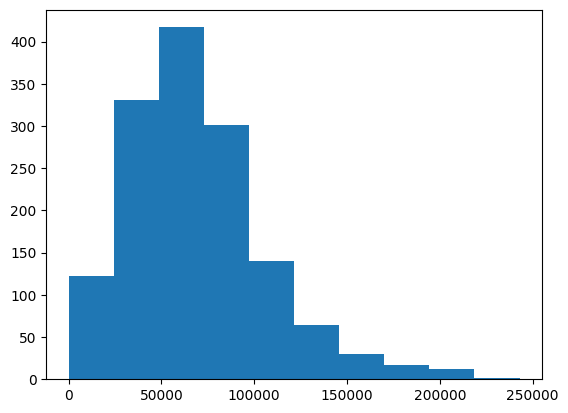

In [7]:
plt.hist(x='KM',data=df)
plt.show()

Scatter plot

Text(0, 0.5, 'Price')

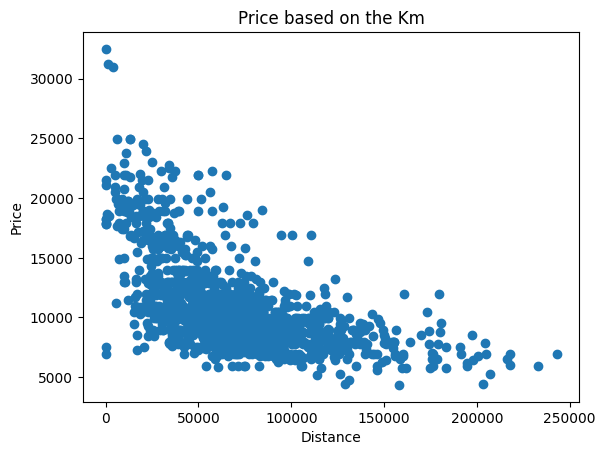

In [8]:
plt.scatter(x='KM',y='Price',data=df)
plt.title('Price based on the Km')
plt.xlabel('Distance')
plt.ylabel('Price')

Text(0, 0.5, 'Price')

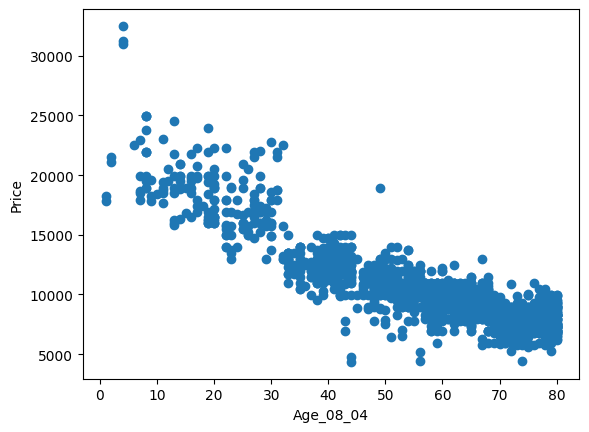

In [9]:
plt.scatter(x='Age_08_04',y='Price',data=df)
plt.xlabel('Age_08_04')
plt.ylabel('Price')

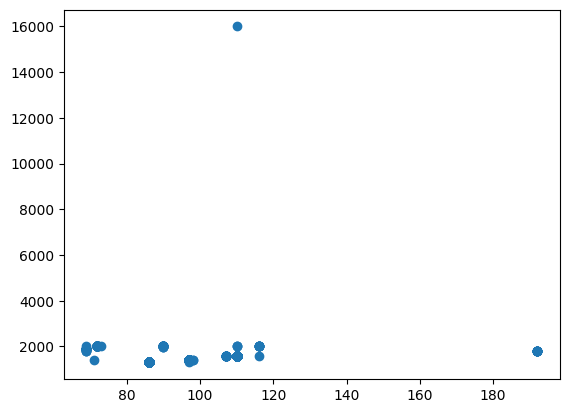

In [10]:
plt.scatter(x='HP',y='cc',data=df)

Cross Tab 

      To chek the correlation between two different (or) indepent  variables.

<Axes: xlabel='Automatic'>

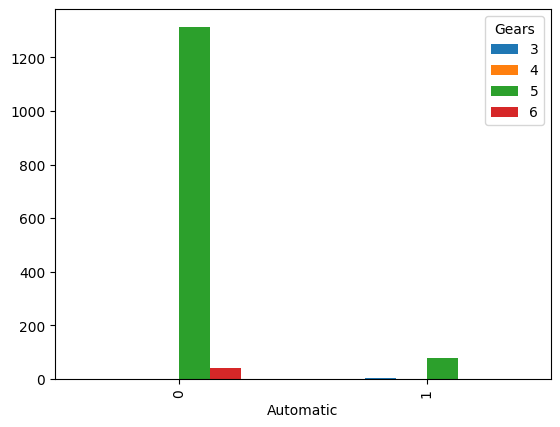

In [11]:
pd.crosstab(df.Automatic,df.Gears).plot(kind='bar')

Label Encoding : convert the categorical variable into numerical variable

In [12]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
df['Fuel_Type']=encoder.fit_transform(df['Fuel_Type'])
df['Fuel_Type']

0       1
1       1
2       1
3       1
4       1
       ..
1431    2
1432    2
1433    2
1434    2
1435    2
Name: Fuel_Type, Length: 1436, dtype: int64

In [13]:
df

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,1,90,0,2000,3,4,5,1165
1,13750,23,72937,1,90,0,2000,3,4,5,1165
2,13950,24,41711,1,90,0,2000,3,4,5,1165
3,14950,26,48000,1,90,0,2000,3,4,5,1165
4,13750,30,38500,1,90,0,2000,3,4,5,1170
...,...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,2,86,0,1300,3,4,5,1025
1432,10845,72,19000,2,86,0,1300,3,4,5,1015
1433,8500,71,17016,2,86,0,1300,3,4,5,1015
1434,7250,70,16916,2,86,0,1300,3,4,5,1015


Spliting the data into x_trian,x_test,y_train,y_test 

In [14]:
from sklearn.model_selection import train_test_split
x=df.drop(columns='Price',axis=1)
y=df['Price']
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.3)


linear Regression

In [15]:
from sklearn.linear_model import LinearRegression
regressor=LinearRegression()
regressor.fit(x_train,y_train)

LinearRegression()

In [16]:
y_pred=regressor.predict(x_test)
y_pred

array([11230.7573348 ,  8993.5345441 ,  9369.12804912,  8971.89766189,
       10098.80423493,  7904.64061239,  8761.12570741,  8291.85499369,
       14123.4729768 , 13134.00826627,  9493.82658736,  9352.98727822,
       12968.2643189 , 13037.01595241,  9820.05656945,  8329.49280526,
       12290.14605042, 17386.13605675,  7479.03001528,  9171.9084571 ,
       12763.61342205, 17786.6921986 ,  7913.01325064, 10467.35760865,
        7566.70092226, 15989.22925997, 10062.54258805,  7422.75401379,
       15629.71133552, 14510.66054119,  8192.50185693,  9780.59852405,
        8525.84839748, 10151.56242431, 10302.43723416,  8081.79125242,
        8884.65367038, 10017.19887485, 16342.38758549,  9622.59742486,
        9883.4894325 ,  9552.20895738,  7895.32250962,  5671.83638888,
        6875.18467069, 17145.35556725,  9486.3783684 , 10721.33191674,
        8780.16305755, 13470.04936756, 13014.51530231,  6395.24394628,
       14920.82714662, 16231.60139592,  6179.28674167,  7785.38954029,
      

In [17]:
from sklearn.metrics import accuracy_score,classification_report

Finding absolute,mean squred,root mean squared errors

In [18]:
from sklearn import metrics
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred, squared=False))

Mean Absolute Error: 981.0058693774421
Mean Squared Error: 1961405.9263851084
Root Mean Squared Error: 1400.5020265551593


c:\Users\shyam\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


coefficients and intercept regressor values

In [19]:
print('Coefficients:', regressor.coef_)
print('Intercept:', regressor.intercept_)

Coefficients: [-1.22096221e+02 -1.66675663e-02  8.42469074e+02  2.06157320e+01
  2.80411323e+02 -3.94681267e-02 -3.10303678e+01  7.38964445e-13
  5.16747344e+02  2.21961245e+01]
Intercept: -11160.493375391325


In [20]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
r2_score_linear=r2_score(y_test,y_pred)
r2_score_linear

0.8591160730499613

DecisionTreeClassifier

In [21]:
from sklearn.tree import DecisionTreeClassifier
tree=DecisionTreeClassifier(random_state=42)
model=tree.fit(x_train,y_train)
model

DecisionTreeClassifier(random_state=42)

In [22]:
y_pred=tree.predict(x_test)
y_pred

array([ 9950,  9450,  8950,  8950,  8950,  6990,  8950,  8950, 11750,
       13995,  9895,  9450, 11695, 10950,  9450,  8950, 10950, 16900,
        7750,  8950, 10950, 17900,  7750,  8950,  7950, 18450, 10995,
        7750, 16250, 12750,  8500,  8900,  7950,  8900,  8900,  7500,
        8250,  9250, 14950,  9500,  8950,  9850,  7990,  6900,  7950,
       16950,  7800,  9500,  8950, 13250, 13950,  7250, 16950, 17950,
        6750,  8900, 11950,  9850, 17450, 13750, 12450,  6900,  7750,
       10950, 13500,  8250, 13500,  7750,  9950,  9450, 21500,  9700,
       12950,  7400, 21750, 12950,  6950,  6900,  7750,  8750, 10450,
        8950, 10900,  9990,  8750,  8950,  9950, 11695, 10450, 10500,
        8250,  5950, 10950,  9450, 11900, 10450, 22250,  7990, 13250,
        9750,  9245,  8750, 10500, 16950,  7600,  7750, 16900,  7750,
        7450,  7950, 11895,  4350,  9450, 12750, 10950, 10500,  6750,
       12900, 11250, 11750,  6640,  6500,  8950, 14950,  9950,  8950,
       13950,  9500,

Accuracy Score

In [23]:
accurcy=accuracy_score(y_test,y_pred)
print(f"accuracy: {accurcy}")
print(classification_report(y_test,y_pred))

accuracy: 0.06728538283062645
              precision    recall  f1-score   support

        4350       0.00      0.00      0.00         0
        4400       0.00      0.00      0.00         0
        4750       0.00      0.00      0.00         1
        5250       0.00      0.00      0.00         2
        5600       0.00      0.00      0.00         1
        5750       0.00      0.00      0.00         1
        5751       0.00      0.00      0.00         0
        5950       0.00      0.00      0.00         4
        6250       0.00      0.00      0.00         1
        6450       0.00      0.00      0.00         2
        6490       0.00      0.00      0.00         0
        6495       0.00      0.00      0.00         1
        6500       0.00      0.00      0.00         1
        6550       0.00      0.00      0.00         1
        6640       0.00      0.00      0.00         0
        6650       0.00      0.00      0.00         2
        6750       0.33      0.12      0.18        

c:\Users\shyam\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\shyam\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\shyam\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, 

R2 score and Mean absoulte error

In [24]:
r2_score1_decision=r2_score(y_test,y_pred)
r2_score1_decision

mean_error_decision=mean_absolute_error(y_test,y_pred)
mean_error_decision

print("R2 score:",r2_score1_decision)
print("mean error:",mean_error_decision)

R2 score: 0.8453676253798572
mean error: 1093.0881670533643


Random Forest Regressor

In [25]:
from sklearn.ensemble import RandomForestRegressor

In [26]:
rfr=RandomForestRegressor(n_estimators=100,random_state=42)
rfr.fit(x_train,y_train)

RandomForestRegressor(random_state=42)

In [27]:
y_pred=rfr.predict(x_test)
y_pred

array([10075.43,  9285.4 ,  8358.97,  7980.4 ,  9763.5 ,  7811.4 ,
        8939.25,  8511.  , 12617.25, 13330.75, 10148.5 ,  9248.6 ,
       12339.6 , 11414.5 ,  9351.4 ,  8822.5 , 11289.15, 17774.5 ,
        7684.9 ,  8169.74, 12443.  , 18432.3 ,  7731.  ,  9813.  ,
        7404.65, 17923.  , 10336.95,  7703.05, 16062.  , 13151.7 ,
        8316.  ,  9383.85,  7822.3 ,  9013.5 ,  9159.35,  7813.4 ,
        8818.45,  9092.  , 15628.  ,  9421.5 ,  9189.  ,  9553.05,
        7963.05,  6736.9 ,  7742.  , 17617.91,  8958.45,  9818.  ,
        9292.3 , 13439.15, 12747.95,  8034.94, 15727.34, 17609.  ,
        7409.  ,  8075.2 , 11178.3 ,  9897.  , 18912.46, 20170.99,
       12471.3 ,  7868.02,  7941.55, 11600.25, 13004.9 ,  9025.  ,
       13427.9 ,  7618.  ,  9204.5 , 10013.3 , 21154.  , 11205.4 ,
       12997.75,  7902.3 , 21157.5 , 11830.5 ,  7770.35,  7663.5 ,
        9601.9 ,  8820.5 , 10304.35,  9236.45, 10857.6 , 10953.3 ,
        7866.85,  7808.  ,  9866.7 , 12468.05,  9137.45, 10975

In [28]:
r2_score_forest=r2_score(y_test,y_pred)
r2_score_forest

squre_error_forest=mean_absolute_error(y_test,y_pred)
squre_error_forest

print("R2 score:",r2_score_forest)
print("mean absolute error:",squre_error_forest)

R2 score: 0.9117101877368463
mean absolute error: 851.4052436194895


#### Models

I observed linear regression model is the best model while comparing to random forest regressor and  DecisionTreeClassifier.

Lasso Regression 

In [29]:
from sklearn.linear_model import Lasso

In [30]:
lasso=Lasso(alpha=0.1)
lasso.fit(x_train,y_train)

y_pred_lasso=lasso.predict(x_test)
y_pred_lasso

array([11231.09144351,  8993.71805458,  9369.37813432,  8972.19818051,
       10099.1467552 ,  7904.80451257,  8761.46178403,  8292.25965414,
       14123.65980381, 13134.32794542,  9493.89382572,  9353.30538828,
       12968.53818201, 13037.2470092 ,  9820.18584844,  8329.52219021,
       12290.3052192 , 17386.12995783,  7478.97442416,  9172.28387115,
       12763.90641736, 17786.83550797,  7913.31176442, 10467.61370183,
        7566.55353676, 15989.36121446, 10060.38449941,  7422.72931093,
       15629.56381534, 14510.99235328,  8192.7134303 ,  9781.1597183 ,
        8526.18973465, 10151.7801247 , 10302.71143068,  8081.99708269,
        8885.00028964, 10017.41822308, 16342.19516468,  9622.60574257,
        9883.81459591,  9552.51399292,  7895.6355868 ,  5671.39020792,
        6875.18909186, 17145.24816303,  9486.60679201, 10721.54381841,
        8780.2572767 , 13470.44291844, 13014.85350575,  6395.32845632,
       14920.51810222, 16231.63400635,  6178.97861781,  7785.6094911 ,
      

In [31]:
r2_score_lasso=r2_score(y_test,y_pred)
r2_score_lasso

squre_error_lasso=mean_absolute_error(y_test,y_pred)
squre_error_lasso

print("r2 score:",r2_score_lasso)
print("mean absolute error:",squre_error_lasso)

r2 score: 0.9117101877368463
mean absolute error: 851.4052436194895


Ridge Regression

In [32]:
from sklearn.linear_model import Ridge

In [33]:
ridge=Ridge(alpha=0.1)
ridge.fit(x_train,y_train)

y_pred_ridge=ridge.predict(x_test)
y_pred_ridge

array([11231.01861989,  8993.59895008,  9369.32282774,  8971.94790375,
       10098.89323409,  7904.54231092,  8761.29504517,  8292.07373277,
       14123.52437483, 13134.1245227 ,  9493.67759828,  9353.15299225,
       12968.35635594, 13037.23697888,  9820.09756628,  8329.4925066 ,
       12290.30313116, 17386.03376777,  7478.9098012 ,  9172.01506994,
       12763.85568849, 17786.75492585,  7913.1393455 , 10467.55022647,
        7566.45507873, 15989.18708427, 10061.74870269,  7422.65456117,
       15629.46117231, 14510.82106405,  8192.58272754,  9780.92427999,
        8525.91941402, 10151.68272422, 10302.60005658,  8081.85504882,
        8884.8436948 , 10017.31792805, 16342.11854914,  9622.44234323,
        9883.68066787,  9552.3800693 ,  7895.362308  ,  5671.45327981,
        6875.14071294, 17145.1322851 ,  9486.49430438, 10721.34001304,
        8780.21653112, 13470.22371145, 13014.76080135,  6395.24783352,
       14920.45043623, 16231.54562093,  6179.01002998,  7785.36173293,
      

In [34]:
r2_score_ridge=r2_score(y_test,y_pred)
r2_score_ridge

mean_error_ridge=mean_absolute_error(y_test,y_pred)
mean_error_ridge

print("R2 score:",r2_score_ridge)
print("mean_absolute_error:",mean_error_ridge)

R2 score: 0.9117101877368463
mean_absolute_error: 851.4052436194895


1) What is Normalization & Standardization and how is it helpful?


Normalization:-


Normalization is a data preprocessing technique that rescales the values of a dataset to a specific range, typically between 0 and 1 or -1 and 1. It helps ensure that each feature contributes equally to the distance calculations in algorithms sensitive to scale.

Standardization :-


Standardization rescales the data so that it has a mean of 0 and a standard deviation of 1. This is particularly useful for datasets that follow a Gaussian distribution and is commonly used in algorithms that assume normally distributed data.

By using normalization and standardization we can improves the algorithm performance , speed up the convergence , better interpretability enhance the model robustness.

2) What techniques can be used to address multicollinearity in multiple linear regression?


We can use remove highly correlated preditors, Combine predictors, Principal component analysis(PCA), Ridge regression, variance inflation factor(VIF), partial least squares(PLS) regression, centering the data, regularization- based method are used to address the multicollinearity in the multiple linear regression. 